/var/folders/35/s39qtbhn2217qdrq2ws5w6j40000gp/T/ipykernel_13269/3656175700.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta0 = torch.tensor(theta0, dtype=torch.float32)


Epoch 0/300, Loss: 0.536128
Epoch 10/300, Loss: 0.495484
Epoch 20/300, Loss: 0.455447
Epoch 30/300, Loss: 0.411747
Epoch 40/300, Loss: 0.361049
Epoch 50/300, Loss: 0.307293
Epoch 60/300, Loss: 0.270436
Epoch 70/300, Loss: 0.268176
Epoch 80/300, Loss: 0.264938
Epoch 90/300, Loss: 0.262817
Epoch 100/300, Loss: 0.261494
Epoch 110/300, Loss: 0.259847
Epoch 120/300, Loss: 0.258306
Epoch 130/300, Loss: 0.256639
Epoch 140/300, Loss: 0.254855
Epoch 150/300, Loss: 0.252946
Epoch 160/300, Loss: 0.250895
Epoch 170/300, Loss: 0.248688
Epoch 180/300, Loss: 0.246306
Epoch 190/300, Loss: 0.243726
Epoch 200/300, Loss: 0.240921
Epoch 210/300, Loss: 0.237854
Epoch 220/300, Loss: 0.234479
Epoch 230/300, Loss: 0.230735
Epoch 240/300, Loss: 0.226539
Epoch 250/300, Loss: 0.221777
Epoch 260/300, Loss: 0.216280
Epoch 270/300, Loss: 0.209797
Epoch 280/300, Loss: 0.201924
Epoch 290/300, Loss: 0.191962


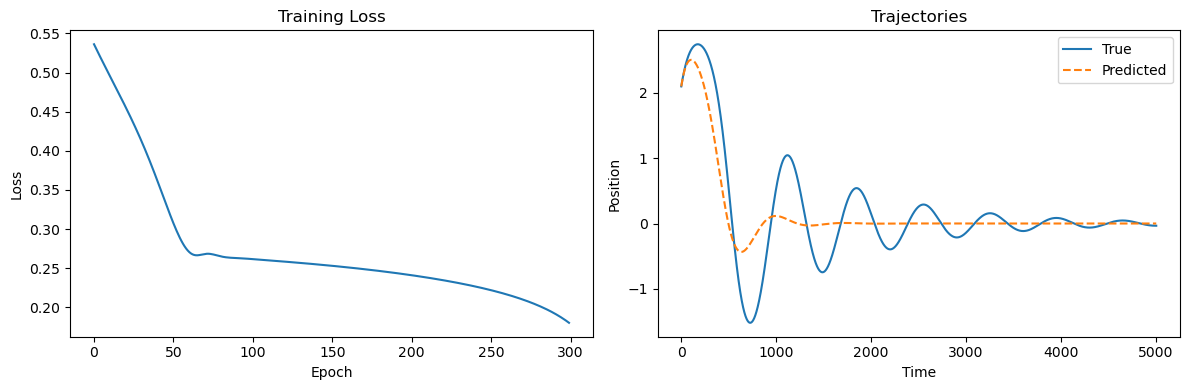


Final Parameters:
Learned m: 0.827, Ground Truth: 1
Learned l: 2.757, Ground Truth: 3.0
Learned b: 1.184, Ground Truth: 0.35


In [60]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class DampedOscillator(nn.Module):
    def __init__(self, dt):
        super().__init__()
        self.m = nn.Parameter(torch.tensor(1.0))
        self.l = nn.Parameter(torch.tensor(1.0))
        self.b = nn.Parameter(torch.tensor(1.0))

        self.g = 9.81
        self.dt = dt
    
    def forward(self, theta0, ts):
        theta0 = torch.tensor(theta0, dtype=torch.float32)

        beta = self.b/(2*self.m)
        omega0 = torch.sqrt(self.g / self.l)

        omegas, thetas = [omega0], [theta0]

        for _ in range(ts - 1):
            theta = thetas[-1]
            omega = omegas[-1]
            
            omega_new = omega + self.dt * (-2 * beta * omega - torch.sin(theta) * omega0**2)
            
            theta_new = theta + self.dt * omega_new
            
            thetas.append(theta_new)
            omegas.append(omega_new)

        return torch.stack(thetas)

def generate_data(T, dt, m = 1, l = 2.25, b = 0.35, g = 9.81):
    Ts = np.arange(0, T + dt, dt)
    beta = b / (2 * m)

    theta0 = 120 * np.pi / 180
    omega0 = np.sqrt(g / l)

    omegas, thetas = [omega0], [theta0]

    for _ in range(len(Ts)+1):
        theta = thetas[-1]
        omega = omegas[-1]
        
        omega_new = omega + dt * (-2 * beta * omega - np.sin(theta) * omega0**2)
        
        theta_new = theta + dt * omega_new
        
        thetas.append(theta_new)
        omegas.append(omega_new)

    return np.stack(thetas)


T, dt = 25, 0.005
m, l, b = 1, 3.0, 0.35

true_trajectory = torch.tensor(generate_data(T, dt, m, l, b), dtype=torch.float32)

# --- TRAIN --- #
model = DampedOscillator(dt)
optim = torch.optim.Adam(model.parameters(), 1e-2)

criterion = nn.MSELoss()
epochs = 300

losses = []
for epoch in range(epochs):
    optim.zero_grad()

    theta0 = true_trajectory[0]
    pred_traj = model(theta0, len(true_trajectory))

    loss = criterion(pred_traj, true_trajectory)

    loss.backward()
    optim.step()

    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f'Epoch {epoch}/{epochs}, Loss: {loss.item():.6f}')
        # print(f'Current omega: {model.omega.item():.3f}, Current a: {model.a.item():.3f}')

# Plot results
plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

plt.subplot(122)
plt.plot(true_trajectory.detach().numpy(), label='True')
plt.plot(pred_traj.detach().numpy(), '--', label='Predicted')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Trajectories')
plt.legend()

plt.tight_layout()
plt.show()


print("\nFinal Parameters:")
print(f"Learned m: {model.m.item():.3f}, Ground Truth: {m}")
print(f"Learned l: {model.l.item():.3f}, Ground Truth: {l}")
print(f"Learned b: {model.b.item():.3f}, Ground Truth: {b}")

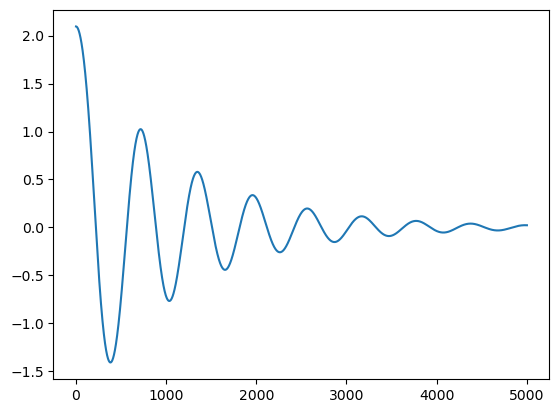

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Dampled Pendulum: https://www.physicsandstuffiguess.com/pendulums/pendulumFriction.html
m = 1
l = 2.25
g = 9.81
b = 0.35
omega0 = np.sqrt(g / l)
beta = b/(2*m)

T = 25
dt = 0.005
Ts = np.arange(0, T + dt, dt)

theta_0 = 120 * np.pi / 180
omega_0 = 0

omegas, thetas = [omega_0], [theta_0]

for i in range(len(Ts)+1):
    omega_new = omegas[i] + dt*-2*beta*omegas[i] -np.sin(thetas[i])*omega0**2
    theta_new = thetas[i] + dt*omega_new

    omegas.append(omega_new)
    thetas.append(theta_new)


plt.plot(thetas)
